# Implementing ANNs with TensorFlow - Homework 02 (Group 4)

## Assignment: Multi-Layer Perceptron

In [13]:
import numpy as np
import matplotlib.pyplot as plt

### Task 01 - Building your data set

In [14]:
# randomly generate the input values
x = np.random.rand(100)
# create the target array (use x^2 - x^3 so the values are positive)
t = x**2 - x**3

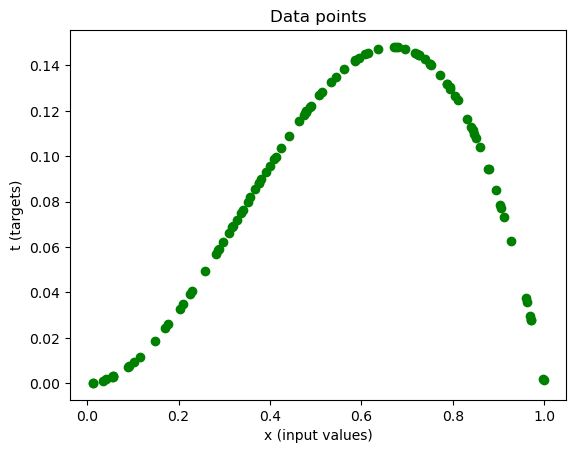

In [15]:
#plot the data points
fig, ax = plt.subplots()

ax.plot(x, t, "go")

ax.set(title = "Data points", xlabel = "x (input values)", ylabel = "t (targets)")

plt.show()

### Task 02 - Perceptrons

In [16]:
# implement the ReLU activation function
def relu(values):
    return np.maximum(0, values)
# implement the derivative of the activation function
relu_derivative= np.vectorize(lambda x: int(x > 0))

In [17]:
class Layer:
    """
    This class implements any given layer of the MLP.
    """
    def __init__(self, n_units, input_units):
        """
        A method that specifies layer attributes.
        
        Arguments:
        n_units -- specifies the number of units in the layer
        input_units -- denotes the number of units in the preceding layer
        """
        # instantiate the bias vector
        self.biases = np.zeros(n_units)
        # instantiate the weights
        rng = np.random.default_rng(seed=42)
        self.weights = rng.integers(-10, 10, (input_units, n_units))
        # instantiate empty attributes for layer input, preactivation, and activation
        self.layer_input = None
        self.layer_preactivation = None
        self.layer_activation = None
        
    def forward_step(self, l_input):
        """
        A method that takes one unit as an input and returns each unit's activation as an output.
        
        Arguments:
        l_input -- specifies the input to the layer
        """
        self.layer_input = l_input
        # calculate the preactivation
        self.layer_preactivation = (self.layer_input @ self.weights) + self.biases
        # apply the activation function
        self.layer_activation = relu(self.layer_preactivation)
        
        return self.layer_activation
    
    def backward_step(self, L_a, alpha):
        """
        A method that updates the weight and bias of each unit.
        
        Arguments:     
        L_a -- denotes the gradient w.r.t. the activation
        alpha -- denotes the learning rate
        """
        # calculate the gradient w.r.t. the weights
        L_W = np.transpose(self.layer_input) @ (relu_derivative(self.layer_preactivation) * L_a)
        # calculate the gradient w.r.t. the bias vector
        L_b = relu_derivative(self.layer_preactivation) * L_a
        # compute the gradient w.r.t. the layer input
        L_input = (relu_derivative(self.layer_preactivation) * L_a) @ np.transpose(self.weights)
        # update the weights
        self.weights = self.weights - alpha * L_W
        # update the biases
        self.biases = self.biases - alpha * L_b
        
        return L_input

### Task 03 - Multi-Layer Perceptron

In [18]:
class MLP:
    """
    A class to represent a multi-layer perceptron using instances of the Layer class.
    """
    def __init__(self, layers):
        """
        The constructor that specifies the attributes of the MLP.
        
        Arguments:
        layers -- a list of Layer objects
        """
        self.layers = layers
    
    def forward_step(self, net_input):
        """
        A method that propagates an input through the entire network.
        
        Arguments:
        net_input -- denotes the input to the network
        """
        net_output = net_input
        # feed the input forward
        for layer in self.layers:
            net_output = layer.forward_step(net_output)
            
        return net_output
    
    def backpropagation(self, loss, alpha):
        """
        A method to update the weights and biases of the network given a loss value.
        
        Arguments:
        loss -- denotes the network error
        alpha -- specifies the learning rate
        """
        temp_loss = loss
        # propagate the error backwards
        for layer in reversed(self.layers):
            loss = layer.backward_step(temp_loss, alpha)

### Task 04 - Training

In [19]:
# we are training for 1000 epochs with a learning rate of 0.005
STEPS = 1000
ALPHA = 0.005

epochs = []
avg_losses = []

# define the layers
hidden_layer = Layer(10, 1)
output_layer = Layer(1, 10)
# create the MLP
mlp = MLP([hidden_layer, output_layer])

# train the MLP
for i in range(STEPS):
    epochs.append(i)
    loss_sum = 0
    
    # iterate over all data points
    for (x_i, t_i) in zip(x, t):
        # calculate prediction
        y = mlp.forward_step(np.array([[x_i]]))
        # calculate the error
        error = ((y - t_i) ** 2)[0] / 2
        loss_sum += error
        # propagate the error backwards
        mlp.backpropagation(np.array([error]), ALPHA)
    # save the average loss after this epoch
    avg_losses.append(loss_sum / len(x))

### Task 05 - Visualization

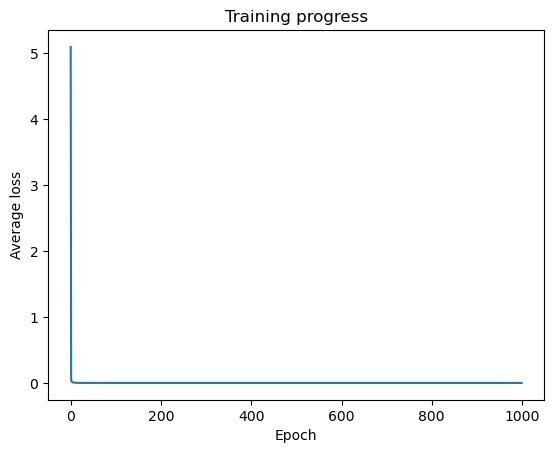

In [20]:
# plot the training progress
fig, ax = plt.subplots()

ax.plot(epochs, avg_losses)
ax.set(title = "Training progress", xlabel = "Epoch", ylabel = "Average loss")

plt.show()

In [21]:
# let's look at the average losses after specific epochs
print("Average losses after...")
print("Epoch 1: ", avg_losses[0][0])
print("Epoch 2: ", avg_losses[1][0])
print("Epoch 5: ", avg_losses[4][0])
print("Epoch 100: ", avg_losses[99][0])
print("Epoch 1000: ", avg_losses[999][0])

Average losses after...
Epoch 1:  5.0964930121420196
Epoch 2:  0.05520150283071474
Epoch 5:  0.014989827577478503
Epoch 100:  0.004898861577759657
Epoch 1000:  0.004898861577759657
